<a href="https://colab.research.google.com/github/LCaravaggio/AnalisisPredictivo/blob/master/04_%C3%81rboles/Bootstrap%20de%20RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

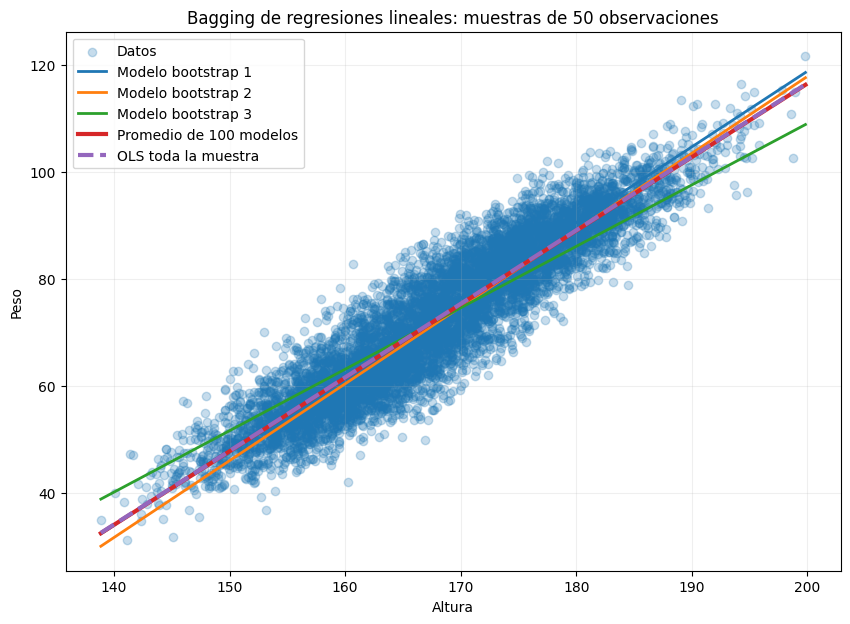

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Cargar datos
url = "https://raw.githubusercontent.com/LCaravaggio/AnalisisPredictivo/refs/heads/master/datos/alturas-pesos.csv"
df = pd.read_csv(url)

X = df[["Altura"]].values
y = df["Peso"].values

# Parámetros
n_modelos = 100
n_muestra = 50

# Grid para graficar las rectas
x_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Guardar predicciones de los 100 modelos
predicciones = np.zeros((len(x_grid), n_modelos))

modelos = []

# 100 modelos, cada uno entrenado con 50 observaciones
for i in range(n_modelos):

    muestra = df.sample(
        n=n_muestra,
        replace=True,
        random_state=i
    )

    X_muestra = muestra[["Altura"]].values
    y_muestra = muestra["Peso"].values

    modelo = LinearRegression()
    modelo.fit(X_muestra, y_muestra)

    modelos.append(modelo)

    predicciones[:, i] = modelo.predict(x_grid)

# Promedio de las 100 regresiones
y_hat_promedio = predicciones.mean(axis=1)

# OLS usando toda la muestra
modelo_ols = LinearRegression()
modelo_ols.fit(X, y)

y_hat_ols = modelo_ols.predict(x_grid)

# --------------------------------------------------
# GRÁFICO
# --------------------------------------------------

plt.figure(figsize=(10, 7))

# Datos originales
plt.scatter(
    X,
    y,
    alpha=0.25,
    label="Datos"
)

# Solo 3 de los 100 modelos
for i in [0, 1, 2]:
    plt.plot(
        x_grid,
        predicciones[:, i],
        linewidth=2,
        label=f"Modelo bootstrap {i+1}"
    )

# Promedio de los 100 modelos
plt.plot(
    x_grid,
    y_hat_promedio,
    linewidth=3,
    label="Promedio de 100 modelos"
)

# OLS sobre toda la muestra
plt.plot(
    x_grid,
    y_hat_ols,
    linestyle="--",
    linewidth=3,
    label="OLS toda la muestra"
)

plt.xlabel("Altura")
plt.ylabel("Peso")
plt.title("Bagging de regresiones lineales: muestras de 50 observaciones")
plt.legend()
plt.grid(alpha=0.2)
plt.show()